# Running Gui
The below input cell can stay hidden. Run it to open the Gui. 

In [3]:
# Sim with GUI
# ToDo: Add types to descriptions
# ToDo: Create specced-down version for less confusion

import seaborn as sns
import plotly.io as pio
import matplotlib.pyplot as plt
import plotly.express as px
import os
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append('../')

from aztec_gddt.experiment import custom_run
from aztec_gddt.default_params import *
from aztec_gddt.types import *

pio.renderers.default = "png"

import ipywidgets as widgets
from IPython.display import display

# Helper functions to create widgets with custom styles.


def create_int_widget(value, description):
    return widgets.IntText(
        value=value,
        description=description,
        # Allocate more space for the label
        style={'description_width': '300px'},
        layout=widgets.Layout(width='600px')   # Keep the input box compact
    )


def create_float_widget(value, description):
    return widgets.FloatText(
        value=value,
        description=description,
        # Allocate more space for the label
        style={'description_width': '300px'},
        layout=widgets.Layout(width='600px')   # Keep the input box compact
    )


def create_dropdown_widget(options, value, description):
    return widgets.Dropdown(
        options=options,
        value=value,
        description=description,
        # Allocate more space for the label
        style={'description_width': '300px'},
        layout=widgets.Layout(width='600px')   # Keep the input box compact
    )


def create_dropdown_widget(options, value, description):
    return widgets.Dropdown(
        options=options,
        value=value,
        description=description,
        style={'description_width': '300px'},
        layout=widgets.Layout(width='600px')
    )



# ===========================
# General Parameters
# ===========================
overhead_widget = create_int_widget(45000, 'OVERHEAD_MANA_PER_TX')
max_mana_widget = create_int_widget(20000000, 'MAXIMUM_MANA_PER_BLOCK')
SIM_TST_TOTAL_SUPPLY_widget = create_int_widget(500000000, 'SIM_TST_TOTAL_SUPPLY')
SIM_LAUNCH_VALUATION_widget = create_int_widget(1500000000, 'SIM_LAUNCH_VALUATION')
l2_slots_widget = create_int_widget(32, 'L2_SLOTS_PER_L2_EPOCH')
l1_slots_widget = create_int_widget(3, 'L1_SLOTS_PER_L2_SLOT')
relative_target_mana_widget = create_float_widget(
    0.5, 'RELATIVE_TARGET_MANA_PER_BLOCK')
blobs_per_block_widget = create_int_widget(3, 'BLOBS_PER_BLOCK')
l1_gas_to_verify_widget = create_int_widget(1000000, 'L1_GAS_TO_VERIFY')
l2_slots_epoch_widget = create_int_widget(32, 'L2_SLOTS_PER_EPOCH')
l1_gas_to_publish_widget = create_int_widget(150000, 'L1_GAS_TO_PUBLISH')
l1_blobgas_per_blob_widget = create_int_widget(131072, 'L1_BLOBGAS_PER_BLOB')
point_eval_widget = create_int_widget(50000, 'POINT_EVALUATION_PRECOMIPLE_GAS')
prover_search_widget = create_int_widget(13, 'PROVER_SEARCH_PERIOD')
min_oracle_lag_widget = create_int_widget(5, 'MIN_ORACLE_UPDATE_LAG_C')

# ===========================
# Fee Parameters
# ===========================

min_multiplier_congestion_widget = create_int_widget(
    1000000, 'MINIMUM_MULTIPLIER_CONGESTION')
max_multiplier_congestion_ratio_widget = create_float_widget(
    10, 'MAXIMUM_MULTIPLIER_CONGESTION_RATIO')
relative_update_frac_congestion_widget = create_float_widget(
    0.5, 'RELATIVE_UPDATE_FRACTION_CONGESTION')
max_relative_change_congestion_widget = create_float_widget(
    0.03, 'MAX_RELATIVE_CHANGE_CONGESTION')
max_update_percentage_widget = create_float_widget(
    0.03, 'MAXIMUM_UPDATE_PERCENTAGE_C')
proving_cost_initial_widget = create_float_widget(
    0.03, 'PROVING_COST_INITIAL_IN_USD_PER_TX_C')

# ===========================
# Block Reward Parameters
# ===========================
block_reward_volatility_widget = create_float_widget(
    3.17e-6, 'BLOCK_REWARD_VOLATILITY')
block_reward_drift_decay_widget = create_float_widget(
    1e-2, 'BLOCK_REWARD_DRIFT_DECAY_RATE')
block_reward_speed_adj_widget = create_float_widget(
    5.5e-4, 'BLOCK_REWARD_SPEED_ADJ')

# ===========================
# Staking Parameters
# ===========================
min_stake_widget = create_int_widget(32, 'MIN_STAKE')
validator_committee_widget = create_int_widget(128, 'VALIDATOR_COMMITTEE_SIZE')
signatures_needed_widget = create_float_widget(0.5, 'SIGNATURES_NEEDED')

# ===========================
# Slashing Parameters
# ===========================
# Replace 1000 with your DEFAULT_BOND_SIZE if needed
bond_size_widget = create_int_widget(1000, 'BOND_SIZE')
bond_slash_percent_widget = create_float_widget(1.0, 'BOND_SLASH_PERCENT')

# ===========================
# Behavioural Parameters
# ===========================
avg_tx_count_widget = create_int_widget(360, 'AVERAGE_TX_COUNT_PER_SLOT')
proving_cost_mod_widget = create_float_widget(
    0.0, 'PROVING_COST_MODIFICATION_E')
fee_juice_price_mod_widget = create_float_widget(
    0.0, 'FEE_JUICE_PRICE_MODIFICATION_E')
oracle_update_freq_widget = create_float_widget(
    0.5, 'ORACLE_UPDATE_FREQUENCY_E')

initial_inflation_widget = create_float_widget(
    0.0, 'INITIAL_INFLATION_ESTIMATE')
max_fee_infl_mean_widget = create_float_widget(
    1.0, 'MAX_FEE_INFLATION_RELATIVE_MEAN')
max_fee_infl_std_widget = create_float_widget(
    0.1, 'MAX_FEE_INFLATION_RELATIVE_STD')
# sequencer_l1_gas_price_threshold_widget = create_float_widget(float('nan'), 'SEQUENCER_L1_GAS_PRICE_THRESHOLD_E')
total_mana_multiplier_widget = create_float_widget(
    1.0, 'TOTAL_MANA_MULTIPLIER_E')
signature_skip_prob_widget = create_float_widget(
    0.0, 'SIGNATURE_SKIP_PROBABILITY')
max_validators_to_slash_widget = create_float_widget(
    0.0, 'MAX_VALIDATORS_TO_SLASH')
prover_quote_lower_bound_widget = create_float_widget(
    0.1, 'PROVER_QUOTE_LOWER_BOUND')
prover_quote_range_widget = create_float_widget(0.8, 'PROVER_QUOTE_RANGE')
prover_quote_mode_widget = create_float_widget(0.3, 'PROVER_QUOTE_MODE')
juice_per_gwei_scenario_widget = create_dropdown_widget(
    ['Stochastic', 'Deterministic'], 'Stochastic', 'JUICE_PER_GWEI_SCENARIO')

# ===========================
# Exogenous Parameters
# ===========================
juice_per_gwei_mean_widget = create_float_widget(1.1e-6, 'JUICE_PER_GWEI_MEAN')
juice_per_gwei_cov_widget = create_float_widget(0.10, 'JUICE_PER_GWEI_COV')
gwei_per_l1gas_mean_widget = create_float_widget(30, 'GWEI_PER_L1GAS_MEAN')
gwei_per_l1gas_cov_widget = create_float_widget(0.01, 'GWEI_PER_L1GAS_COV')
gwei_per_l1blobgas_mean_widget = create_float_widget(
    5, 'GWEI_PER_L1BLOBGAS_MEAN')
gwei_per_l1blobgas_cov_widget = create_float_widget(
    0.05, 'GWEI_PER_L1BLOBGAS_COV')

market_price_eth_widget = create_int_widget(3300, 'market_price_eth')


# ===========================
# Simulation Run Settings
# ===========================
N_timesteps_widget = widgets.IntSlider(
    value=100, min=10, max=10000, description='N Timesteps')
# N_samples_widget = widgets.IntSlider(
#     value=1, min=1, max=1, description='N Samples')

# ===========================
# Organize Widgets into Sections
# ===========================
general_params = widgets.VBox([
    overhead_widget, max_mana_widget, SIM_TST_TOTAL_SUPPLY_widget, SIM_LAUNCH_VALUATION_widget,
    l2_slots_widget, l1_slots_widget, prover_search_widget, min_oracle_lag_widget, relative_target_mana_widget, blobs_per_block_widget, l1_gas_to_verify_widget, l2_slots_epoch_widget,
    l1_gas_to_publish_widget, l1_blobgas_per_blob_widget, point_eval_widget
])

fee_params = widgets.VBox([
    
    min_multiplier_congestion_widget, max_multiplier_congestion_ratio_widget,
    relative_update_frac_congestion_widget, max_relative_change_congestion_widget,
    max_update_percentage_widget, proving_cost_initial_widget
])

reward_params = widgets.VBox([
    block_reward_volatility_widget, block_reward_drift_decay_widget, block_reward_speed_adj_widget
])

staking_params = widgets.VBox([
    min_stake_widget, validator_committee_widget, signatures_needed_widget
])

# slashing_params = widgets.VBox([
#     bond_size_widget, bond_slash_percent_widget
# ])
# Bug: Bond size widget messes up sim, check and debug

slashing_params = widgets.VBox([
    bond_slash_percent_widget
])

behavioural_params = widgets.VBox([
    avg_tx_count_widget, proving_cost_mod_widget, fee_juice_price_mod_widget, oracle_update_freq_widget,
    initial_inflation_widget,
    max_fee_infl_mean_widget, max_fee_infl_std_widget, 
    total_mana_multiplier_widget, signature_skip_prob_widget, max_validators_to_slash_widget,
    prover_quote_lower_bound_widget, prover_quote_range_widget, prover_quote_mode_widget
])

exogenous_params = widgets.VBox([
    juice_per_gwei_mean_widget, juice_per_gwei_cov_widget, gwei_per_l1gas_mean_widget, gwei_per_l1gas_cov_widget,
    gwei_per_l1blobgas_mean_widget, gwei_per_l1blobgas_cov_widget,
    market_price_eth_widget
])

simulation_params = widgets.VBox([N_timesteps_widget])

# Use an Accordion to group sections
accordion = widgets.Accordion(children=[
    simulation_params,
    general_params,
    fee_params,
    reward_params,
    staking_params,
    slashing_params,
    behavioural_params,
    exogenous_params
    
])
accordion.set_title(0, 'Simulation Settings')
accordion.set_title(1, 'General Parameters')
accordion.set_title(2, 'Fee Parameters')
accordion.set_title(3, 'Block Reward Parameters')
accordion.set_title(4, 'Staking Parameters')
accordion.set_title(5, 'Slashing Parameters')
accordion.set_title(6, 'Behavioural Parameters')
accordion.set_title(7, 'Exogenous Parameters')


display(accordion)

# ===========================
# Run Button and Simulation Trigger
# ===========================
run_button = widgets.Button(
    description="Run Simulation", button_style='success')


def run_simulation(b):
    # Declare sim_df as global so it is accessible in later cells.
    global sim_df

    params_to_modify = {
        # General parameters
        'OVERHEAD_MANA_PER_TX': [overhead_widget.value],
        'MAXIMUM_MANA_PER_BLOCK': [max_mana_widget.value],
        'SIM_TST_TOTAL_SUPPLY': [SIM_TST_TOTAL_SUPPLY_widget.value],
        'SIM_LAUNCH_VALUATION': [SIM_LAUNCH_VALUATION_widget.value],
        'L2_SLOTS_PER_L2_EPOCH': [l2_slots_widget.value],
        'L1_SLOTS_PER_L2_SLOT': [l1_slots_widget.value],
        'PROVER_SEARCH_PERIOD': [prover_search_widget.value],
        'MIN_ORACLE_UPDATE_LAG_C': [min_oracle_lag_widget.value],
        'RELATIVE_TARGET_MANA_PER_BLOCK': [relative_target_mana_widget.value],
        'BLOBS_PER_BLOCK': [blobs_per_block_widget.value],
        'L1_GAS_TO_VERIFY': [l1_gas_to_verify_widget.value],
        'L2_SLOTS_PER_EPOCH': [l2_slots_epoch_widget.value],
        'L1_GAS_TO_PUBLISH': [l1_gas_to_publish_widget.value],
        'L1_BLOBGAS_PER_BLOB': [l1_blobgas_per_blob_widget.value],
        'POINT_EVALUATION_PRECOMIPLE_GAS': [point_eval_widget.value],
        # Fee parameters
        'MINIMUM_MULTIPLIER_CONGESTION': [min_multiplier_congestion_widget.value],
        'MAXIMUM_MULTIPLIER_CONGESTION_RATIO': [max_multiplier_congestion_ratio_widget.value],
        'RELATIVE_UPDATE_FRACTION_CONGESTION': [relative_update_frac_congestion_widget.value],
        'MAX_RELATIVE_CHANGE_CONGESTION': [max_relative_change_congestion_widget.value],
        'MAXIMUM_UPDATE_PERCENTAGE_C': [max_update_percentage_widget.value],
        'PROVING_COST_INITIAL_IN_USD_PER_TX_C': [proving_cost_initial_widget.value],
        # Block Reward parameters
        'BLOCK_REWARD_VOLATILITY': [block_reward_volatility_widget.value],
        'BLOCK_REWARD_DRIFT_DECAY_RATE': [block_reward_drift_decay_widget.value],
        'BLOCK_REWARD_SPEED_ADJ': [block_reward_speed_adj_widget.value],
        # Staking parameters
        'MIN_STAKE': [min_stake_widget.value],
        'VALIDATOR_COMMITTEE_SIZE': [validator_committee_widget.value],
        'SIGNATURES_NEEDED': [signatures_needed_widget.value],
        # Slashing parameters
        # 'BOND_SIZE': [bond_size_widget.value],
        'BOND_SLASH_PERCENT': [bond_slash_percent_widget.value],
        # # Behavioural parameters
        'AVERAGE_TX_COUNT_PER_SLOT': [avg_tx_count_widget.value],
        'PROVING_COST_MODIFICATION_E': [proving_cost_mod_widget.value],
        'FEE_JUICE_PRICE_MODIFICATION_E': [fee_juice_price_mod_widget.value],
        'ORACLE_UPDATE_FREQUENCY_E': [oracle_update_freq_widget.value],
        
        'INITIAL_INFLATION_ESTIMATE': [initial_inflation_widget.value],
        'MAX_FEE_INFLATION_RELATIVE_MEAN': [max_fee_infl_mean_widget.value],
        'MAX_FEE_INFLATION_RELATIVE_STD': [max_fee_infl_std_widget.value],
        
        'TOTAL_MANA_MULTIPLIER_E': [total_mana_multiplier_widget.value],
        'SIGNATURE_SKIP_PROBABILITY': [signature_skip_prob_widget.value],
        'MAX_VALIDATORS_TO_SLASH': [max_validators_to_slash_widget.value],
        'PROVER_QUOTE_LOWER_BOUND': [prover_quote_lower_bound_widget.value],
        'PROVER_QUOTE_RANGE': [prover_quote_range_widget.value],
        'PROVER_QUOTE_MODE': [prover_quote_mode_widget.value],
        # Exogenous parameters
        'JUICE_PER_GWEI_MEAN': [juice_per_gwei_mean_widget.value],
        'JUICE_PER_GWEI_COV': [juice_per_gwei_cov_widget.value],
        'GWEI_PER_L1GAS_MEAN': [gwei_per_l1gas_mean_widget.value],
        'GWEI_PER_L1GAS_COV': [gwei_per_l1gas_cov_widget.value],
        'GWEI_PER_L1BLOBGAS_MEAN': [gwei_per_l1blobgas_mean_widget.value],
        'GWEI_PER_L1BLOBGAS_COV': [gwei_per_l1blobgas_cov_widget.value],
        'market_price_eth': [market_price_eth_widget.value],
    }
    N_timesteps = N_timesteps_widget.value
    # N_samples = N_samples_widget.value
    try:
        sim_df = custom_run(N_timesteps=N_timesteps,
                            N_samples=1,
                            params_to_modify=params_to_modify)
        print("Simulation complete!")
        # Optionally, visualize or further analyze sim_df
    except Exception as e:
        print("An error occurred during simulation:", e)

    # # Run your simulation using the collected parameters
    # sim_df = custom_run(N_timesteps=N_timesteps,
    #                     N_samples=N_samples,
    #                     params_to_modify=params_to_modify)
    # print("Simulation complete!")


run_button.on_click(run_simulation)
display(run_button)

Accordion(children=(VBox(children=(IntSlider(value=100, description='N Timesteps', max=10000, min=10),)), VBox…

Button(button_style='success', description='Run Simulation', style=ButtonStyle())

In [5]:
# Let's grab the final row of our state measurements and do some sanity checks.  
sim_df.iloc[-1]

index                       700
timestep                    100
l1_blocks_passed            100
delta_l1_blocks               1
l2_blocks_passed             34
                           ... 
L2_SLOTS_PER_EPOCH           32
BOND_SLASH_PERCENT          1.0
PROVER_QUOTE_LOWER_BOUND    0.1
PROVER_QUOTE_RANGE          0.8
PROVER_QUOTE_MODE           0.3
Name: 100, Length: 113, dtype: object

In [6]:
# Grabbing df columns to decide on further data to investigate. 
sim_df.columns

Index(['index', 'timestep', 'l1_blocks_passed', 'delta_l1_blocks',
       'l2_blocks_passed', 'agents', 'validator_set', 'current_epoch',
       'last_epoch', 'last_reward_time_in_l1',
       ...
       'EXPECTED_PROOFS_CURRENT_EPOCH_PER_TS',
       'MIN_FRACTION_COMPLETE_PROOF_LAST_EPOCH',
       'MAX_FRACTION_COMPLETE_PROOF_LAST_EPOCH', 'market_price_eth',
       'PROVER_SEARCH_PERIOD', 'L2_SLOTS_PER_EPOCH', 'BOND_SLASH_PERCENT',
       'PROVER_QUOTE_LOWER_BOUND', 'PROVER_QUOTE_RANGE', 'PROVER_QUOTE_MODE'],
      dtype='object', length=113)

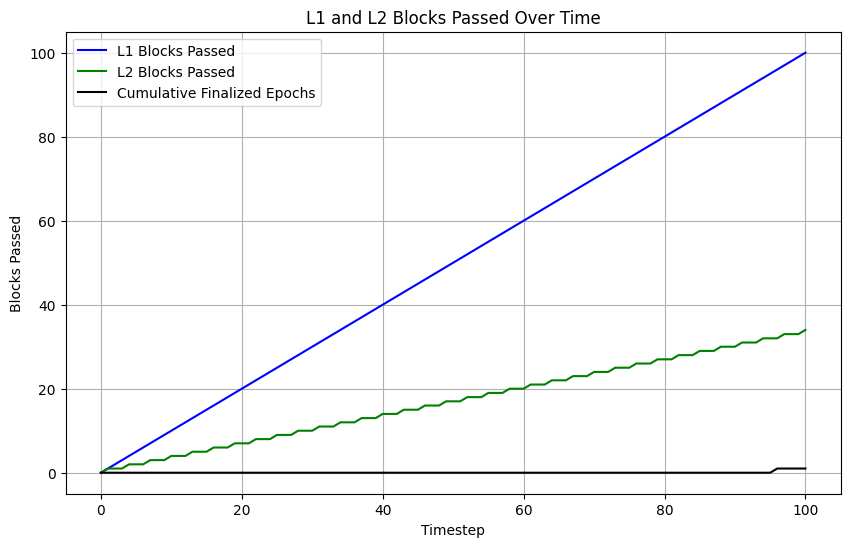

In [7]:
# Time series plot for L1 blocks vs L2 blocks vs cumulatively finalized epochs for sanity checking. 
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['l1_blocks_passed'], label='L1 Blocks Passed', color='blue')
plt.plot(sim_df['timestep'], sim_df['l2_blocks_passed'], label='L2 Blocks Passed', color='green')
plt.plot(sim_df['timestep'], sim_df['cumm_finalized_epochs'], label='Cumulative Finalized Epochs', color='black')

plt.title('L1 and L2 Blocks Passed Over Time')
plt.xlabel('Timestep')
plt.ylabel('Blocks Passed')
plt.legend()
plt.grid(True)
plt.show()

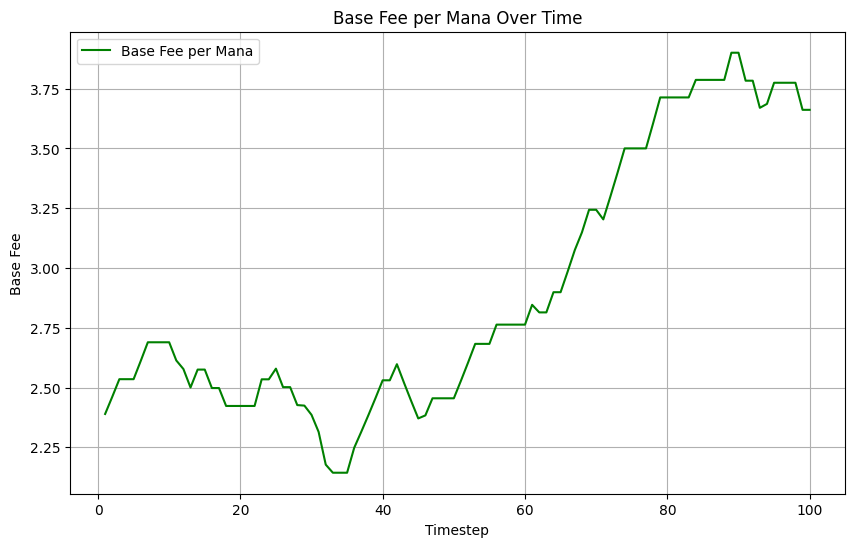

In [8]:
# Base Fee per Mana over Time 
plt.figure(figsize=(10, 6))
plt.plot(sim_df['timestep'], sim_df['base_fee'], label='Base Fee per Mana', color='green')
plt.title('Base Fee per Mana Over Time')
plt.xlabel('Timestep')
plt.ylabel('Base Fee')
plt.legend()
plt.grid(True)
plt.show()

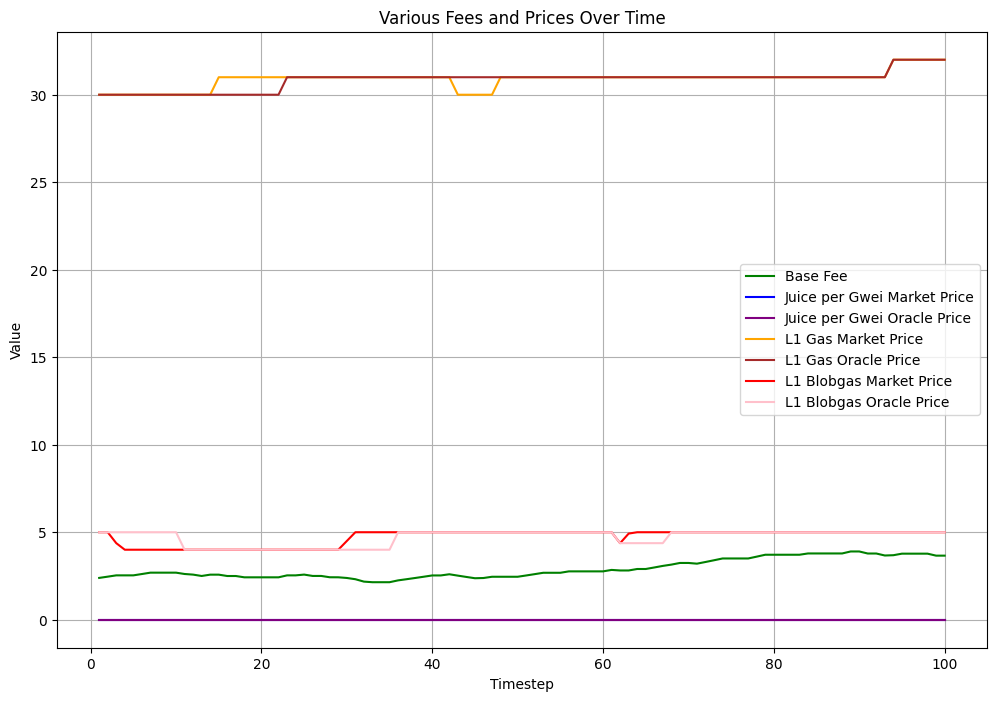

In [9]:
# Base Fee Components over Time 
# 1 axis, removed congestion multiplier 
# ToDo: Juice per Gwei different magnitude

plt.figure(figsize=(12, 8))

# Plot the different variables over time (timestep)
plt.plot(sim_df['timestep'], sim_df['base_fee'], label='Base Fee', color='green')
plt.plot(sim_df['timestep'], sim_df['market_price_juice_per_gwei'], label='Juice per Gwei Market Price', color='blue')
plt.plot(sim_df['timestep'], sim_df['oracle_price_juice_per_gwei'], label='Juice per Gwei Oracle Price', color='purple')
plt.plot(sim_df['timestep'], sim_df['market_price_l1_gas'], label='L1 Gas Market Price', color='orange')
plt.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'], label='L1 Gas Oracle Price', color='brown')
plt.plot(sim_df['timestep'], sim_df['market_price_l1_blobgas'], label='L1 Blobgas Market Price', color='red')
plt.plot(sim_df['timestep'], sim_df['oracle_price_l1_blobgas'], label='L1 Blobgas Oracle Price', color='pink')
#plt.plot(sim_df['timestep'], sim_df['congestion_multiplier'], label='Congestion Multiplier', color='black')

# Title and labels
plt.title('Various Fees and Prices Over Time')
plt.xlabel('Timestep')
plt.ylabel('Value')

# Adding a legend to distinguish the lines
plt.legend()

# Display the grid
plt.grid(True)

# Show the plot
plt.show()

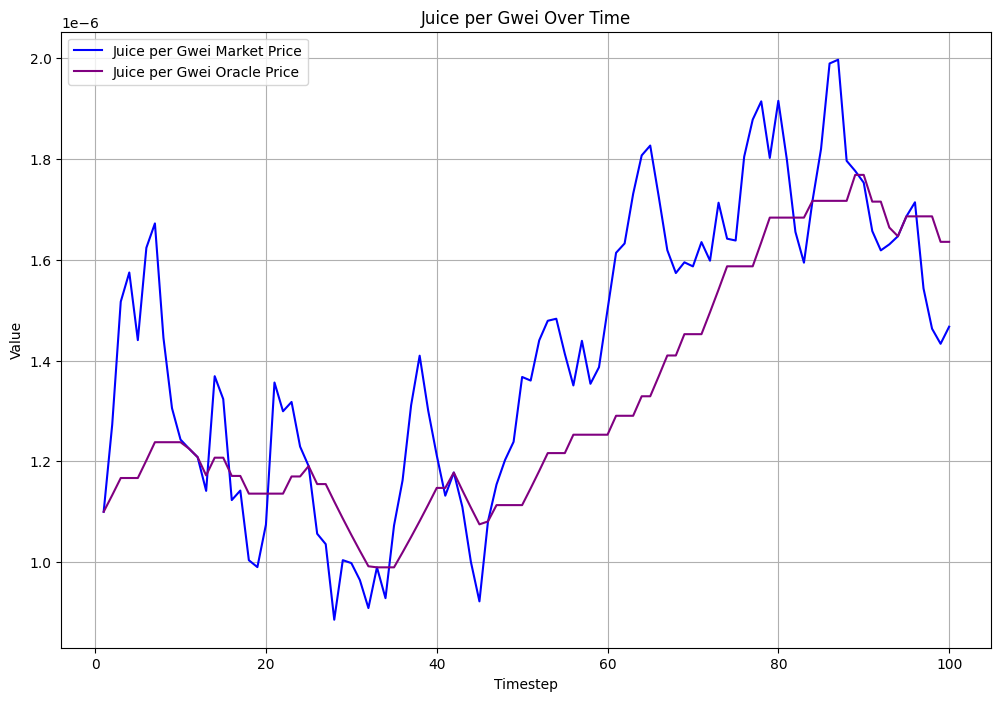

In [10]:
# Juice per Gwei over time 

plt.figure(figsize=(12, 8))
plt.plot(sim_df['timestep'], sim_df['market_price_juice_per_gwei'], label='Juice per Gwei Market Price', color='blue')
plt.plot(sim_df['timestep'], sim_df['oracle_price_juice_per_gwei'], label='Juice per Gwei Oracle Price', color='purple')

# Title and labels
plt.title('Juice per Gwei Over Time')
plt.xlabel('Timestep')
plt.ylabel('Value')

# Adding a legend to distinguish the lines
plt.legend()

# Display the grid
plt.grid(True)

# Show the plot
plt.show()

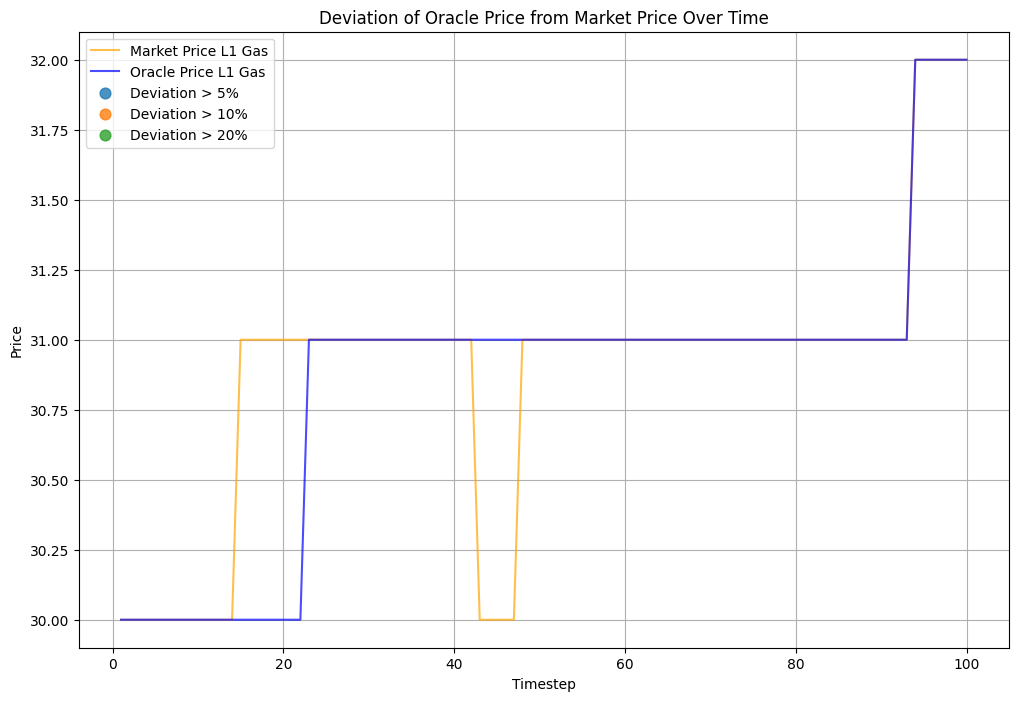

In [11]:
# Plotting whenever Oracle Price lag deviates by X% from Market Price
import matplotlib.pyplot as plt
import numpy as np

# Calculate the percentage difference between oracle and market prices
sim_df['percentage_diff'] = np.abs(
    (sim_df['oracle_price_l1_gas'] - sim_df['market_price_l1_gas']) / sim_df['market_price_l1_gas']) * 100

# Define % thresholds for deviations
thresholds = [5, 10, 20]

# Create a plot for each threshold
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the market price and oracle price for reference
ax.plot(sim_df['timestep'], sim_df['market_price_l1_gas'],
        label='Market Price L1 Gas', color='orange', alpha=0.7)
ax.plot(sim_df['timestep'], sim_df['oracle_price_l1_gas'],
        label='Oracle Price L1 Gas', color='blue', alpha=0.7)

# Highlight the timesteps where the deviation exceeds each threshold
for threshold in thresholds:
    # Identify the timesteps where the percentage difference exceeds the threshold
    above_threshold = sim_df[sim_df['percentage_diff'] >= threshold]

    # Plot vertical lines at the timesteps where the deviation exceeds the threshold
    ax.scatter(above_threshold['timestep'], above_threshold['oracle_price_l1_gas'],
               label=f'Deviation > {threshold}%', marker='o', s=60, alpha=0.8)

# Set labels, title, and legend
ax.set_xlabel('Timestep')
ax.set_ylabel('Price', color='black')
ax.tick_params(axis='y', labelcolor='black')
ax.set_title('Deviation of Oracle Price from Market Price Over Time')

# Display grid
ax.grid(True)

# Add a legend
ax.legend(loc='upper left')

# Show the plot
plt.show()